In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pymodels
import pyaccel as pa

In [3]:
model = pymodels.si.create_accelerator()
model[18].pass_method

'str_mpole_symplectic4_pass'

Looking at the normalized fields $G(s)$ and $K_1(s)$ across Sirius

Plotting the fields' profiles for a single sector (*sector 1 of 20*)

energy         : 3000000000.0 eV
harmonic_number: 864
cavity_on      : False
radiation_on   : 0
vchamber_on    : False
lattice version: 
lattice size   : 27647
lattice length : 518.3898999999151 m


<Figure size 640x480 with 0 Axes>

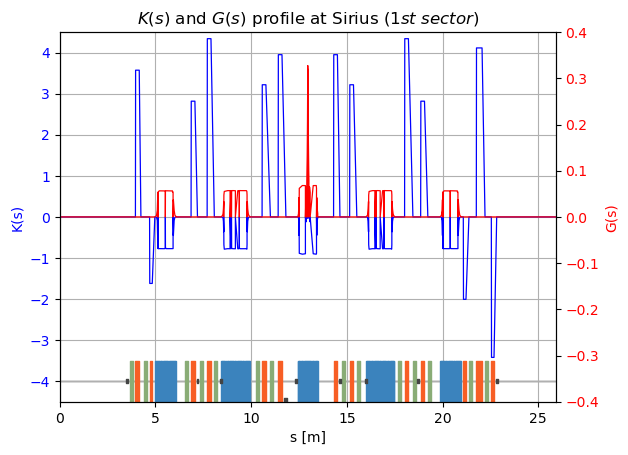

In [4]:
plt.figure()

model1 = pa.lattice.refine_lattice(model, 0.005, pass_methods=['str_mpole_symplectic4_pass'])

print(model1)

K = [e.K for e in model1]
G = [e.angle/e.length if e.length != 0 else 0 for e in model1]
s = np.cumsum([e.length for e in model1])

fig, ax1 = plt.subplots()

# Left y-axis (K)
ax1.plot(s, K, color='blue', label='K(s)', linewidth=0.9)
ax1.set_xlabel('s [m]')
ax1.set_ylabel('K(s)', color='blue')
ax1.set_xlim(0, s[-1]/20)
ax1.set_ylim(-4.5, 4.5)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True)

# Right y-axis (G)
ax2 = ax1.twinx()
ax2.plot(s, G, color='red', label='G(s)', linewidth=0.9)
ax2.set_ylabel('G(s)', color='red')
ax2.set_ylim(-0.4, 0.4)
ax2.tick_params(axis='y', labelcolor='red')

# Title
plt.title(r'$K(s)$ and $G(s)$ profile at Sirius ($1st$ $sector$)')

# Lattice drawing (keep it tied to ax1)
pa.graphics.draw_lattice(model, offset=-4, gca=ax1)

plt.show()

Looking at the fields for a whole Unit Cell

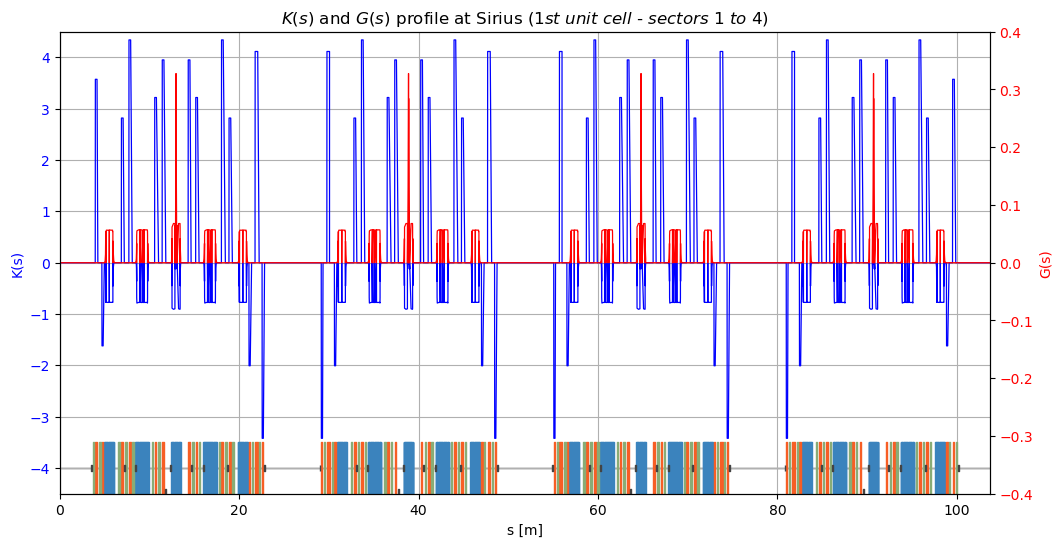

In [5]:
fig, ax1 = plt.subplots(figsize = (12, 6))

# Left y-axis (K)
ax1.plot(s, K, color='blue', label='K(s)', linewidth=0.9)
ax1.set_xlabel('s [m]')
ax1.set_ylabel('K(s)', color='blue')
ax1.set_xlim(0, s[-1]/5)
ax1.set_ylim(-4.5, 4.5)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True)

# Right y-axis (G)
ax2 = ax1.twinx()
ax2.plot(s, G, color='red', label='G(s)', linewidth=0.9)
ax2.set_ylabel('G(s)', color='red')
ax2.set_ylim(-0.4, 0.4)
ax2.tick_params(axis='y', labelcolor='red')

# Title
plt.title(r'$K(s)$ and $G(s)$ profile at Sirius ($1st$ $unit$ $cell$ - $sectors$ $1$ $to$ $4$)')

# Lattice drawing (keep it tied to ax1)
pa.graphics.draw_lattice(model, offset=-4, gca=ax1)

plt.show()

Looking at the 5-symmetry

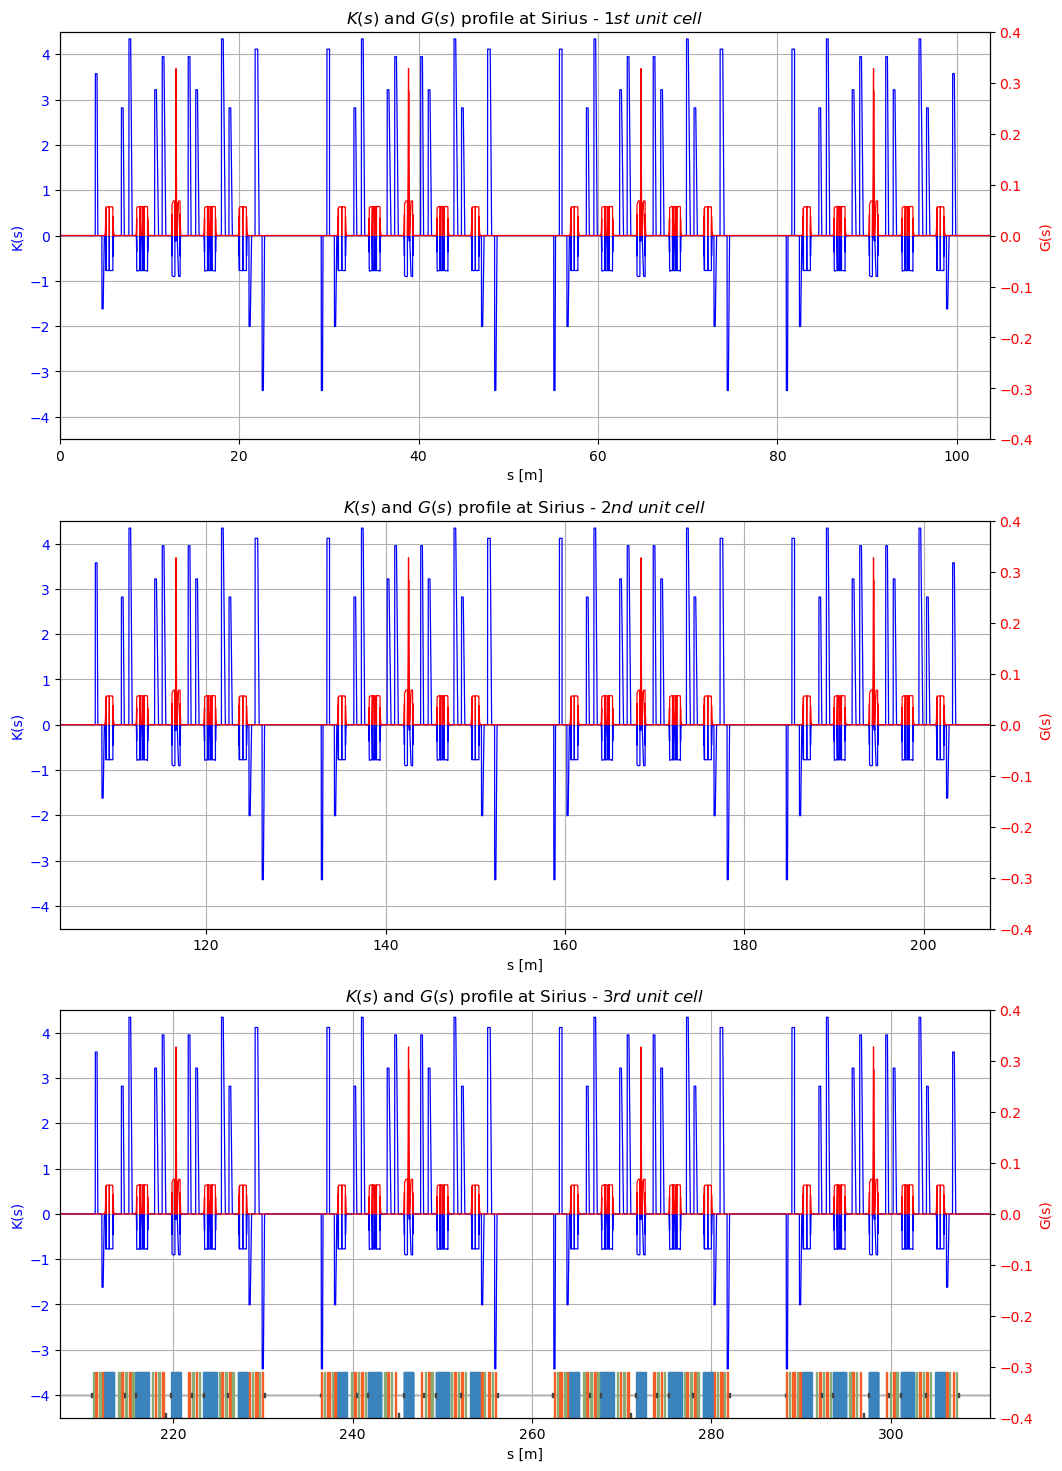

In [6]:
delta_s = s[-1]/5

fig, axes = plt.subplots(3, 1, figsize = (12, 3*6))

for i in range(len(axes)):
    axi = axes[i]
    # Left y-axis (K)
    axi.plot(s, K, color='blue', label='K(s)', linewidth=0.9)
    axi.set_xlabel('s [m]')
    axi.set_ylabel('K(s)', color='blue')
    axi.set_xlim(i*delta_s, (i+1)*delta_s)
    axi.set_ylim(-4.5, 4.5)
    axi.tick_params(axis='y', labelcolor='blue')
    axi.grid(True)

    # Right y-axis (G)
    axi2 = axi.twinx()
    axi2.plot(s, G, color='red', label='G(s)', linewidth=0.9)
    axi2.set_ylabel('G(s)', color='red')
    axi2.set_ylim(-0.4, 0.4)
    axi2.tick_params(axis='y', labelcolor='red')

    # Title
    if not i:
        axi.set_title(r'$K(s)$ and $G(s)$ profile at Sirius - $1st$ $unit$ $cell$')
    elif i==1:
        axi.set_title(r'$K(s)$ and $G(s)$ profile at Sirius - $2nd$ $unit$ $cell$')
    else:
        axi.set_title(r'$K(s)$ and $G(s)$ profile at Sirius - $3rd$ $unit$ $cell$')
# Lattice drawing (keep it tied to the last axi)
pa.graphics.draw_lattice(model, offset=-4, gca=axi)

plt.show()

Checking scales / typical values of $K_1$, $G$ and $G^2$ for quadrupoles and dipoles in Sirius

In [7]:
fam_data = pymodels.si.get_family_data(model)
print('QFAs:', fam_data['QFA']['index'])
print('B1s:', fam_data['B1']['index'])

QFAs: [[18], [1334], [1358], [2680], [2702], [4028], [4052], [5380], [5404], [6729]]
B1s: [[29, 30, 31, 32, 34, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 62, 63, 64, 65], [279, 280, 281, 282, 284, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 312, 313, 314, 315], [366, 367, 368, 369, 371, 373, 374, 375, 376, 377, 378, 379, 380, 381, 382, 383, 386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 399, 400, 401, 402], [616, 617, 618, 619, 621, 623, 624, 625, 626, 627, 628, 629, 630, 631, 632, 633, 636, 637, 638, 639, 640, 641, 642, 643, 644, 645, 646, 647, 649, 650, 651, 652], [701, 702, 703, 704, 706, 708, 709, 710, 711, 712, 713, 714, 715, 716, 717, 718, 721, 722, 723, 724, 725, 726, 727, 728, 729, 730, 731, 732, 734, 735, 736, 737], [951, 952, 953, 954, 956, 958, 959, 960, 961, 962, 963, 964, 965, 966, 967, 968, 971, 972, 973, 974, 975, 976, 977, 978, 979, 980, 

In [12]:
QFA1 = model[18]
print(QFA1, '\n')
B1_1 = model[43] # Taking an element at the center of the dipole to avoid the changing fields at the edges
print(B1_1)

fam_name   : QFA 
pass_method: str_mpole_symplectic4_pass 
length     : 0.2 m
nr_steps   : 14 
polynom_b  : [ 0.00000000e+00  3.57317772e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -6.33975204e+04  0.00000000e+00  0.00000000e+00
  0.00000000e+00  1.37951798e+13  0.00000000e+00  0.00000000e+00
  0.00000000e+00 -2.61580732e+20] 1/m¹, 1/m², 1/m³, ...
vchamber   : 2 
hmin       : -0.012 m
hmax       : 0.012 m
vmin       : -0.012 m
vmax       : 0.012 m 

fam_name   : B1 
pass_method: bnd_mpole_symplectic4_pass 
length     : 0.005 m
angle      : 0.000279776279094691 rad
polynom_b  : [ 0.0000e+00 -7.5771e-01 -1.0657e-02  3.5007e+00  2.9571e+02 -1.7742e+03
 -2.0010e+06] 1/m¹, 1/m², 1/m³, ...
vchamber   : 2 
hmin       : -0.012 m
hmax       : 0.012 m
vmin       : -0.012 m
vmax       : 0.012 m


In [14]:
K1 = QFA1.K  
QFA_length = QFA1.length
print(f'QFA_1:\nK1 = {K1:.3f} m⁻²', f'\nl = {QFA_length:.3f} m', f'\nK1*l = {K1*QFA_length:.3f} m⁻¹', f'\nQFA1.KL = {QFA1.KL:.3f} m⁻¹')
print(f'dtheta = {QFA1.angle:.5f} rad')

delta_theta = B1_1.angle
B_length = B1_1.length
rho = B_length/delta_theta
print(f'\nBC_1:\ndtheta = {delta_theta:.5f} rad', f'\nl = {B_length:.3f} m', f'\nrho = {rho:.3f} m', f'\nG = {1/rho:.3f} m⁻¹', f'\nG² = {1/rho**2:.2e} m⁻²')

print(f'Thus, K1 is {K1*rho**2:.3f} times bigger than G²')

QFA_1:
K1 = 3.573 m⁻² 
l = 0.200 m 
K1*l = 0.715 m⁻¹ 
QFA1.KL = 0.715 m⁻¹
dtheta = 0.00000 rad

BC_1:
dtheta = 0.00028 rad 
l = 0.005 m 
rho = 17.871 m 
G = 0.056 m⁻¹ 
G² = 3.13e-03 m⁻²
Thus, K1 is 1141.229 times bigger than G²


Checking angle swept when passing through the whole model:

In [ ]:
print(f'dtheta full orbit = {np.sum([elem.angle for elem in model]):.8f} rad = ({np.sum([elem.angle for elem in model])/2/np.pi:.3f})*2π rad')

dtheta full orbit = 6.28318531 rad = (1.000)*2π rad
